## Video to csv

In [1]:
import cv2
import time
import torch
import argparse
import numpy as np
from utils.datasets import letterbox
from utils.torch_utils import select_device
from models.experimental import attempt_load
from utils.plots import output_to_keypoint, plot_skeleton_kpts
from utils.general import non_max_suppression_kpt, strip_optimizer
from torchvision import transforms
import csv

# 計算三點形成的角度
def calculate_angle(a, b, c):
    """
    計算以b為頂點，a和c構成的角度。
    :param a: 第一點 [x, y]
    :param b: 頂點 [x, y]
    :param c: 第二點 [x, y]
    :return: 角度 (度數)
    """
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ab = a - b
    cb = c - b

    cosine_angle = np.dot(ab, cb) / (np.linalg.norm(ab) * np.linalg.norm(cb))
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))  # 避免浮點數超界
    return np.degrees(angle)

@torch.no_grad()
def run(source):
    path = source
    ext = path.split('/')[-1].split('.')[-1].strip().lower()
    if ext in ["mp4", "webm", "avi"] or ext not in ["mp4", "webm", "avi"] and ext.isnumeric():
        input_path = int(path) if path.isnumeric() else path
        device = select_device('0')
        half = device.type != 'cpu'
        model = attempt_load('yolov7-w6-pose.pt', map_location=device)
        _ = model.eval()

        cap = cv2.VideoCapture(input_path)
        if not cap.isOpened():
            print('Error while trying to read video. Please check path again')

        frame_width, frame_height = int(cap.get(3)), int(cap.get(4))
        vid_write_image = letterbox(
            cap.read()[1], (frame_width), stride=64, auto=True)[0]
        resize_height, resize_width = vid_write_image.shape[:2]
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        out_video_name = "output" if path.isnumeric() else f"{input_path.split('/')[-1].split('.')[0]}"
        out = cv2.VideoWriter(f"{out_video_name}_result_with_angles.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (resize_width, resize_height))

        csv_file = "ankle_coordinates_with_angles.csv"
        file = open(csv_file, mode='w', newline='')
        writer = csv.writer(file)
        writer.writerow(['Frame', 'Right_Knee_Angle', 'Left_Knee_Angle'])

        frame_count, total_fps = 0, 0

        while cap.isOpened():
            print(f"Frame {frame_count} Processing")
            ret, frame = cap.read()
            if ret:
                orig_image = frame

                # preprocess image
                image = cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB)
                image = letterbox(image, (frame_width), stride=64, auto=True)[0]
                image = transforms.ToTensor()(image)
                image = torch.tensor(np.array([image.numpy()]))

                image = image.to(device)
                image = image.float()
                start_time = time.time()

                with torch.no_grad():
                    output, _ = model(image)

                output = non_max_suppression_kpt(output, 0.35, 0.7, nc=model.yaml['nc'], nkpt=model.yaml['nkpt'], kpt_label=True)
                output = output_to_keypoint(output)
                img = image[0].permute(1, 2, 0) * 255
                img = img.cpu().numpy().astype(np.uint8)
                img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

                for idx in range(output.shape[0]):
                    joints_list = plot_skeleton_kpts(img, output[idx, 7:].T, 3)

                    # 提取所需關鍵點座標
                    Right_Hip = joints_list[12]
                    Right_Knee = joints_list[14]
                    Right_Ankle = joints_list[16]

                    Left_Hip = joints_list[11]
                    Left_Knee = joints_list[13]
                    Left_Ankle = joints_list[15]

                    # 計算角度
                    right_knee_angle = calculate_angle(Right_Hip, Right_Knee, Right_Ankle)
                    left_knee_angle = calculate_angle(Left_Hip, Left_Knee, Left_Ankle)

                    # 在影像上顯示角度
                    cv2.putText(img, f"RK: {right_knee_angle:.1f}", (int(Right_Knee[0]), int(Right_Knee[1]) - 20),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
                    cv2.putText(img, f"LK: {left_knee_angle:.1f}", (int(Left_Knee[0]), int(Left_Knee[1]) - 20),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

                    # 保存到 CSV
                    writer.writerow([frame_count, right_knee_angle, left_knee_angle])

                if ext.isnumeric():
                    cv2.imshow("Detection", img)
                    key = cv2.waitKey(1)
                    if key == ord('c'):
                        break

                end_time = time.time()
                fps = 1 / (end_time - start_time)
                total_fps += fps
                frame_count += 1
                out.write(img)
            else:
                break

        cap.release()
        avg_fps = total_fps / frame_count
        print(f"Average FPS: {avg_fps:.3f}")
        file.close()

if __name__ == "__main__":
    outpath = "video/EDC.mp4"
    run(outpath)


c:\Users\user\anaconda3\envs\pose\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fusing layers... 
Frame 0 Processing


c:\Users\user\anaconda3\envs\pose\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3191.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Frame 1 Processing
Frame 2 Processing
Frame 3 Processing
Frame 4 Processing
Frame 5 Processing
Frame 6 Processing
Frame 7 Processing
Frame 8 Processing
Frame 9 Processing
Frame 10 Processing
Frame 11 Processing
Frame 12 Processing
Frame 13 Processing
Frame 14 Processing
Frame 15 Processing
Frame 16 Processing
Frame 17 Processing
Frame 18 Processing
Frame 19 Processing
Frame 20 Processing
Frame 21 Processing
Frame 22 Processing
Frame 23 Processing
Frame 24 Processing
Frame 25 Processing
Frame 26 Processing
Frame 27 Processing
Frame 28 Processing
Frame 29 Processing
Frame 30 Processing
Frame 31 Processing
Frame 32 Processing
Frame 33 Processing
Frame 34 Processing
Frame 35 Processing
Frame 36 Processing
Frame 37 Processing
Frame 38 Processing
Frame 39 Processing
Frame 40 Processing
Frame 41 Processing
Frame 42 Processing
Frame 43 Processing
Frame 44 Processing
Frame 45 Processing
Frame 46 Processing
Frame 47 Processing
Frame 48 Processing
Frame 49 Processing
Frame 50 Processing
Frame 51 

In [2]:
import cv2
import time
import torch
import argparse
import numpy as np
from utils.datasets import letterbox
from utils.torch_utils import select_device
from models.experimental import attempt_load
from utils.plots import output_to_keypoint, plot_skeleton_kpts
from utils.general import non_max_suppression_kpt, strip_optimizer
from torchvision import transforms
import csv

@torch.no_grad()
def run(source):

    path = source
    ext = path.split('/')[-1].split('.')[-1].strip().lower()
    if ext in ["mp4", "webm", "avi"] or ext not in ["mp4", "webm", "avi"] and ext.isnumeric():
        input_path = int(path) if path.isnumeric() else path
        device = select_device('0')
        half = device.type != 'cpu'
        model = attempt_load('yolov7-w6-pose.pt', map_location=device)
        _ = model.eval()

        cap = cv2.VideoCapture(input_path)

        if (cap.isOpened() == False):
            print('Error while trying to read video. Please check path again')

        frame_width, frame_height = int(cap.get(3)), int(cap.get(4))

        vid_write_image = letterbox(
            cap.read()[1], (frame_width), stride=64, auto=True)[0]
        resize_height, resize_width = vid_write_image.shape[:2]
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        # image_transparent = np.zeros((resize_height,resize_width,3),np.uint8) # 透明畫布
        out_video_name = "output" if path.isnumeric else f"{input_path.split('/')[-1].split('.')[0]}"
        out = cv2.VideoWriter(f"{out_video_name}_result.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (resize_width, resize_height))

        csv_file = "ankle_coordinates.csv"
        file = open(csv_file, mode='w', newline='')  # 提前打開文件
        writer = csv.writer(file)
        writer.writerow(['Frame', 'Right_Ankle_X', 'Right_Ankle_Y', 'Left_Ankle_X', 'Left_Ankle_Y'])

        frame_count, total_fps = 0, 0

        while cap.isOpened:

            print(f"Frame {frame_count} Processing")
            ret, frame = cap.read()
            if ret:
                orig_image = frame

                # preprocess image
                image = cv2.cvtColor(orig_image, cv2.COLOR_BGR2RGB)
                image = letterbox(image, (frame_width), stride=64, auto=True)[0]
                image_ = image.copy()
                image = transforms.ToTensor()(image)
                image = torch.tensor(np.array([image.numpy()]))

                image = image.to(device)
                image = image.float()
                start_time = time.time()

                with torch.no_grad():
                    output, _ = model(image)

                # output = non_max_suppression_kpt(output, 0.25, 0.65, nc=model.yaml['nc'], nkpt=model.yaml['nkpt'], kpt_label=True)
                output = non_max_suppression_kpt(output, 0.35, 0.7, nc=model.yaml['nc'], nkpt=model.yaml['nkpt'], kpt_label=True)
                output = output_to_keypoint(output)
                img = image[0].permute(1, 2, 0) * 255
                img = img.cpu().numpy().astype(np.uint8)
                img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

                for idx in range(output.shape[0]):
                    joints_list = plot_skeleton_kpts(img, output[idx, 7:].T, 3)
                    
                    Right_Ankle = joints_list[16]
                    Left_Ankle = joints_list[15]

                    writer.writerow([frame_count, Right_Ankle[0], Right_Ankle[1], Left_Ankle[0], Left_Ankle[1]])

                if ext.isnumeric():
                    cv2.imshow("Detection", img)
                    key = cv2.waitKey(1)
                    if key == ord('c'):
                        break

                end_time = time.time()
                fps = 1 / (end_time - start_time)
                total_fps += fps
                frame_count += 1
                out.write(img)
            else:
                break

        cap.release()
        avg_fps = total_fps / frame_count
        print(f"Average FPS: {avg_fps:.3f}")

if __name__ == "__main__":
    outpath = "video/EDC.mp4"
    run(outpath)

Fusing layers... 
Frame 0 Processing
Frame 1 Processing
Frame 2 Processing
Frame 3 Processing
Frame 4 Processing
Frame 5 Processing
Frame 6 Processing
Frame 7 Processing
Frame 8 Processing
Frame 9 Processing
Frame 10 Processing
Frame 11 Processing
Frame 12 Processing
Frame 13 Processing
Frame 14 Processing
Frame 15 Processing
Frame 16 Processing
Frame 17 Processing
Frame 18 Processing
Frame 19 Processing
Frame 20 Processing
Frame 21 Processing
Frame 22 Processing
Frame 23 Processing
Frame 24 Processing
Frame 25 Processing
Frame 26 Processing
Frame 27 Processing
Frame 28 Processing
Frame 29 Processing
Frame 30 Processing
Frame 31 Processing
Frame 32 Processing
Frame 33 Processing
Frame 34 Processing
Frame 35 Processing
Frame 36 Processing
Frame 37 Processing
Frame 38 Processing
Frame 39 Processing
Frame 40 Processing
Frame 41 Processing
Frame 42 Processing
Frame 43 Processing
Frame 44 Processing
Frame 45 Processing
Frame 46 Processing
Frame 47 Processing
Frame 48 Processing
Frame 49 Pro

## Savitzky-Golay 濾波器

有效波峰已保存至 'valid_peaks.csv'


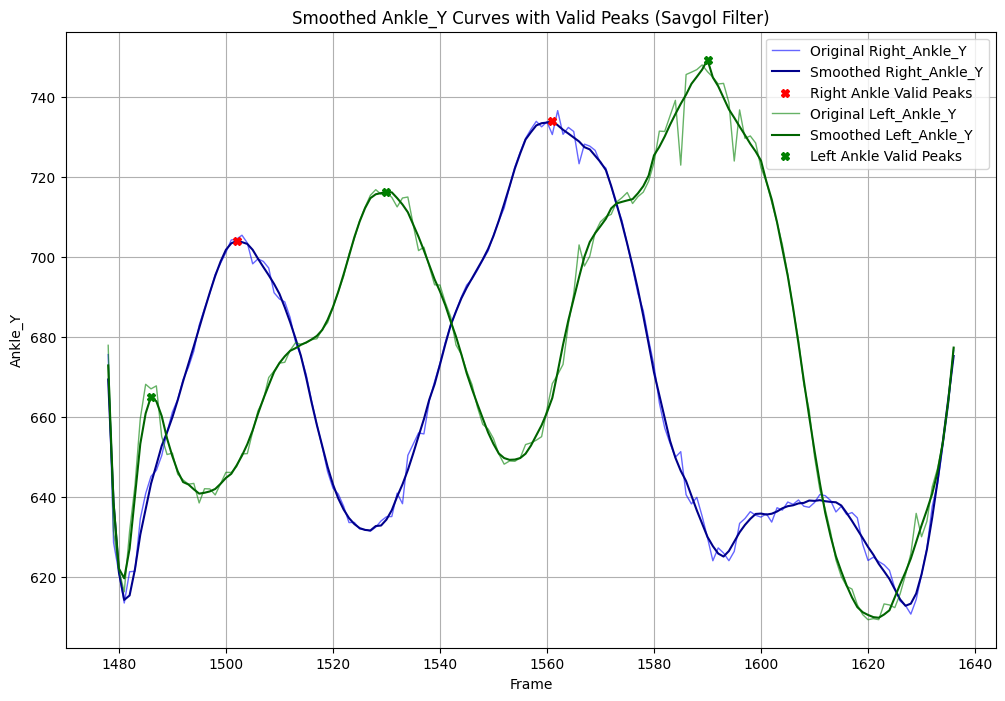

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_prominences, savgol_filter

# 讀取 CSV 文件
# file_path = 'ankle_coordinates.csv'
file_path = 'D:/pose_estimation/static/jobs/Rec_419cd0ae/Rec_419cd0ae_pose.csv'
data = pd.read_csv(file_path)

# 提取所需欄位
frames = data['Frame']
right_y_values = data['Right_Ankle_Y']
right_x_values = data['Right_Ankle_X']
left_y_values = data['Left_Ankle_Y']
left_x_values = data['Left_Ankle_X']

# 使用 Savitzky-Golay 濾波器平滑數據
window_length = 11  # 濾波窗口大小，必須為奇數
polyorder = 3       # 多項式階數

smoothed_right_y_values = savgol_filter(right_y_values, window_length, polyorder)
smoothed_left_y_values = savgol_filter(left_y_values, window_length, polyorder)

# 檢測右腳波峰
right_peaks, _ = find_peaks(smoothed_right_y_values)
right_prominences = peak_prominences(smoothed_right_y_values, right_peaks)[0]
right_valid_peaks = right_peaks[right_prominences > 20]  # 顯著性閾值可調整

# 檢測左腳波峰
left_peaks, _ = find_peaks(smoothed_left_y_values)
left_prominences = peak_prominences(smoothed_left_y_values, left_peaks)[0]
left_valid_peaks = left_peaks[left_prominences > 20]

# 提取右腳有效波峰的幀數、X、Y 座標
right_peak_data = pd.DataFrame({
    'Frame_Right': frames.iloc[right_valid_peaks].values,
    'X_Right': right_x_values.iloc[right_valid_peaks].values,
    'Y_Right': smoothed_right_y_values[right_valid_peaks]
})

# 提取左腳有效波峰的幀數、X、Y 座標
left_peak_data = pd.DataFrame({
    'Frame_Left': frames.iloc[left_valid_peaks].values,
    'X_Left': left_x_values.iloc[left_valid_peaks].values,
    'Y_Left': smoothed_left_y_values[left_valid_peaks]
})

# 合併左右腳波峰數據，按需要保存
peak_data = pd.concat([right_peak_data, left_peak_data], axis=1)
peak_data.to_csv('valid_peaks.csv', index=False)

print("有效波峰已保存至 'valid_peaks.csv'")

# 繪製曲線並標記有效波峰
plt.figure(figsize=(12, 8))

# 右腳曲線與波峰
plt.plot(frames, right_y_values, label='Original Right_Ankle_Y', linewidth=1, alpha=0.6, color='blue')
plt.plot(frames, smoothed_right_y_values, label='Smoothed Right_Ankle_Y', linewidth=1.5, color='darkblue')
plt.plot(right_peak_data['Frame_Right'], right_peak_data['Y_Right'], 'rX', label='Right Ankle Valid Peaks')  # 右腳波峰

# 左腳曲線與波峰
plt.plot(frames, left_y_values, label='Original Left_Ankle_Y', linewidth=1, alpha=0.6, color='green')
plt.plot(frames, smoothed_left_y_values, label='Smoothed Left_Ankle_Y', linewidth=1.5, color='darkgreen')
plt.plot(left_peak_data['Frame_Left'], left_peak_data['Y_Left'], 'gX', label='Left Ankle Valid Peaks')  # 左腳波峰

# 美化圖表
plt.title('Smoothed Ankle_Y Curves with Valid Peaks (Savgol Filter)')
plt.xlabel('Frame')
plt.ylabel('Ankle_Y')
plt.legend()
plt.grid(True)
plt.show()


## 時間

In [ ]:
import cv2
import pandas as pd
import numpy as np

# 讀取波峰資訊
csv_file = 'valid_peaks.csv'
peak_data = pd.read_csv(csv_file)

# 合併左右腳的標記，並按幀數排序
all_peaks = []
if 'Frame_Right' in peak_data and 'X_Right' in peak_data:
    all_peaks.extend([(row['Frame_Right'], row['X_Right'], 'Right') for _, row in peak_data.iterrows() if not pd.isna(row['Frame_Right'])])
if 'Frame_Left' in peak_data and 'X_Left' in peak_data:
    all_peaks.extend([(row['Frame_Left'], row['X_Left'], 'Left') for _, row in peak_data.iterrows() if not pd.isna(row['Frame_Left'])])
all_peaks.sort(key=lambda x: x[0])  # 按幀數排序

# 影片路徑
input_video = 'output_result.mp4'
output_video = 'pose_with_intervals.mp4'

cap = cv2.VideoCapture(input_video)
if not cap.isOpened():
    print('Error: Unable to open video file.')
    exit()

# 影片屬性
fps = int(cap.get(cv2.CAP_PROP_FPS))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# 初始化影片寫入器
out = cv2.VideoWriter(output_video, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

# 創建持久化畫布
persistent_canvas = np.zeros((frame_height, frame_width, 3), dtype=np.uint8)

# 初始化變數
last_peak_frame = None

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # 檢查當前幀是否有標記
    for peak_frame, x, label in all_peaks:
        if frame_count == peak_frame:
            x = int(x)
            # 繪製垂直線
            color = (0, 0, 255) if label == 'Right' else (0, 255, 0)  # 右腳紅色，左腳綠色
            cv2.line(persistent_canvas, (x, 0), (x, frame_height), color, 2)

            # 計算並顯示時間間隔
            if last_peak_frame is not None:
                interval = (frame_count - last_peak_frame) / fps  # 計算時間間隔
                text = f'{interval:.2f}s'
                cv2.putText(persistent_canvas, text, (x + 10, round(frame_height // 2 * 1.4)), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)  # 黃色文字顯示間隔
            last_peak_frame = frame_count

    # 疊加畫布到當前幀
    overlay_frame = cv2.addWeighted(frame, 1.0, persistent_canvas, 0.7, 0)

    # 寫入處理後的幀
    out.write(overlay_frame)
    frame_count += 1

cap.release()
out.release()
print(f"Processed video saved as: {output_video}")


Processed video saved as: pose_with_intervals.mp4


## 步頻

In [ ]:
import cv2
import pandas as pd
import numpy as np

# 設定比例尺（每像素的真實距離，例如每像素0.02米）
pixel_to_meter_ratio = 0.0098  # 每像素代表的距離（單位：米）

# 讀取波峰資訊
csv_file = 'valid_peaks.csv'
peak_data = pd.read_csv(csv_file)

# 合併左右腳的標記，並按幀數排序
all_peaks = []
if 'Frame_Right' in peak_data and 'X_Right' in peak_data:
    all_peaks.extend([(row['Frame_Right'], row['X_Right'], 'Right') for _, row in peak_data.iterrows() if not pd.isna(row['Frame_Right'])])
if 'Frame_Left' in peak_data and 'X_Left' in peak_data:
    all_peaks.extend([(row['Frame_Left'], row['X_Left'], 'Left') for _, row in peak_data.iterrows() if not pd.isna(row['Frame_Left'])])
all_peaks.sort(key=lambda x: x[0])  # 按幀數排序

# 影片路徑
input_video = 'output_result.mp4'
output_video = 'pose_with_real_stride_lengths.mp4'

cap = cv2.VideoCapture(input_video)
if not cap.isOpened():
    print('Error: Unable to open video file.')
    exit()

# 影片屬性
fps = int(cap.get(cv2.CAP_PROP_FPS))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# 初始化影片寫入器
out = cv2.VideoWriter(output_video, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

# 創建持久化畫布
persistent_canvas = np.zeros((frame_height, frame_width, 3), dtype=np.uint8)

# 初始化變數
last_peak = None  # 記錄上一個標記（包含幀數和 X 座標）

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # 檢查當前幀是否有標記
    for peak_frame, x, label in all_peaks:
        if frame_count == peak_frame:
            x = int(x)
            # 繪製垂直線
            color = (0, 0, 255) if label == 'Right' else (0, 255, 0)  # 右腳紅色，左腳綠色
            cv2.line(persistent_canvas, (x, 0), (x, frame_height), color, 2)

            # 計算真實步幅
            if last_peak is not None:
                last_frame, last_x, last_label = last_peak
                if label != last_label:  # 只有左右腳切換時才計算步幅
                    stride_length_px = abs(x - last_x)  # 計算像素步幅
                    stride_length_m = stride_length_px * pixel_to_meter_ratio  # 換算為真實距離
                    text = f'{stride_length_m:.2f}m'
                    mid_x = (x + last_x) // 2  # 設置文字顯示位置
                    mid_y = frame_height // 2 + 30
                    cv2.putText(persistent_canvas, text, (mid_x, mid_y), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)  # 黃色文字顯示真實步幅

            last_peak = (frame_count, x, label)

    # 疊加畫布到當前幀
    overlay_frame = cv2.addWeighted(frame, 1.0, persistent_canvas, 0.7, 0)

    # 寫入處理後的幀
    out.write(overlay_frame)
    frame_count += 1

cap.release()
out.release()
print(f"Processed video saved as: {output_video}")


Processed video saved as: pose_with_real_stride_lengths.mp4


## 速度

In [ ]:
import cv2
import pandas as pd
import numpy as np

# 設定比例尺（每像素的真實距離，例如每像素0.02米）
pixel_to_meter_ratio = 0.0098  # 每像素代表的距離（單位：米）

# 讀取波峰資訊
csv_file = 'valid_peaks.csv'
peak_data = pd.read_csv(csv_file)

# 合併左右腳的標記，並按幀數排序
all_peaks = []
if 'Frame_Right' in peak_data and 'X_Right' in peak_data:
    all_peaks.extend([(row['Frame_Right'], row['X_Right'], 'Right') for _, row in peak_data.iterrows() if not pd.isna(row['Frame_Right'])])
if 'Frame_Left' in peak_data and 'X_Left' in peak_data:
    all_peaks.extend([(row['Frame_Left'], row['X_Left'], 'Left') for _, row in peak_data.iterrows() if not pd.isna(row['Frame_Left'])])
all_peaks.sort(key=lambda x: x[0])  # 按幀數排序

# 影片路徑
input_video = 'output_result.mp4'
output_video = 'pose_with_speed.mp4'

cap = cv2.VideoCapture(input_video)
if not cap.isOpened():
    print('Error: Unable to open video file.')
    exit()

# 影片屬性
fps = int(cap.get(cv2.CAP_PROP_FPS))
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# 初始化影片寫入器
out = cv2.VideoWriter(output_video, cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

# 創建持久化畫布
persistent_canvas = np.zeros((frame_height, frame_width, 3), dtype=np.uint8)

# 初始化變數
last_peak = None  # 記錄上一個標記（包含幀數和 X 座標）

frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # 檢查當前幀是否有標記
    for peak_frame, x, label in all_peaks:
        if frame_count == peak_frame:
            x = int(x)
            # 繪製垂直線
            color = (0, 0, 255) if label == 'Right' else (0, 255, 0)  # 右腳紅色，左腳綠色
            cv2.line(persistent_canvas, (x, 0), (x, frame_height), color, 2)

            # 計算步幅和速度
            if last_peak is not None:
                last_frame, last_x, last_label = last_peak
                if label != last_label:  # 只有左右腳切換時才計算
                    # 計算步幅（真實距離）
                    stride_length_px = abs(x - last_x)  # 像素步幅
                    stride_length_m = stride_length_px * pixel_to_meter_ratio  # 真實距離

                    # 計算時間間隔
                    time_interval = (frame_count - last_frame) / fps  # 時間間隔

                    # 計算速度
                    if time_interval > 0:
                        speed = stride_length_m / time_interval  # 速度 = 距離 / 時間
                        text_speed = f'{speed:.2f} m/s'
                        mid_x = (x + last_x) // 2  # 設置文字顯示位置
                        mid_y_speed = frame_height // 2 + 60
                        cv2.putText(persistent_canvas, text_speed, (mid_x, mid_y_speed), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)  # 白色文字顯示速度

                    # 顯示步幅
                    text_stride = f'{stride_length_m:.2f}m'
                    mid_y_stride = frame_height // 2 + 30
                    cv2.putText(persistent_canvas, text_stride, (mid_x, mid_y_stride), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)  # 黃色文字顯示步幅

            last_peak = (frame_count, x, label)

    # 疊加畫布到當前幀
    overlay_frame = cv2.addWeighted(frame, 1.0, persistent_canvas, 0.7, 0)

    # 寫入處理後的幀
    out.write(overlay_frame)
    frame_count += 1

cap.release()
out.release()
print(f"Processed video saved as: {output_video}")


Processed video saved as: pose_with_speed.mp4
